This is code that:
1. Generates matrices with hub-node interactions (functions from metaCommunityMx.py)
2. Samples uniformly at random some species from the matrices, runs deterministic GLV, and stores simulated data
3. Calculates co-occurrence matrix as covariance between abundance vectors
4. Calculates centrality metrics and tests whether those are good predictors of hub nodes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from sklearn import metrics

import metaCommunityMx
import community_sim
import metrics_and_plotting
import run_cooccurrence

reload(metaCommunityMx)
reload(community_sim)
reload(metrics_and_plotting)
reload(run_cooccurrence)

import pickle, os
os.makedirs('figure_data', exist_ok=True)

1. Generate matrices

In [3]:
interactFactor = 1/5
nSpec = 100
nModules = 5
pPositive = 0.1
n_matrices = 20

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor

# confidence set for cutoff
pval_alpha = 0.01

# for less perfect hubs
pWithinMod = 0.01
pBetweenMod = 0.01
pHub = 0.9

b_L = [np.ones(nSpec) - np.random.uniform(low=0, high=0.1, size=(nSpec)) 
       for i in range(n_matrices)]

zeroMx = np.zeros(shape = (nSpec, nSpec))
hubMx_perf = metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = 0, pBetweenMod = 0, nModules = nModules, pHub = 0.9)
hubMxL = [metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = pBetweenMod, nModules = nModules, pHub = pHub)
            for i in range(n_matrices)]

3. Calculates co-occurrence matrix

In [4]:
network_hubL = list()
network_hub_perfL = list()

print("imperfect")
for i in range(n_matrices):
    network_hub, G_hub = run_cooccurrence.get_coocc_network(
        interactionMx=hubMxL[i], 
        cutoff=None,  # calculate null cutoffs
        alpha=alpha, 
        spsamplesize=samplesize, 
        numtrials=numtrials, 
        b=b_L[i], 
        tmax=100, 
        plotNetworks=False, 
        pval_alpha=pval_alpha
    )
    network_hubL.append(network_hub)

print("perfect")
for i in range(n_matrices):
    network_hub_perf, G_hub_perf = run_cooccurrence.get_coocc_network(
        interactionMx=hubMx_perf, 
        cutoff=None, 
        alpha=alpha, 
        spsamplesize=samplesize, 
        numtrials=numtrials, 
        b=b_L[i], 
        tmax=100, 
        plotNetworks=False, 
        pval_alpha=pval_alpha
    )
    network_hub_perfL.append(network_hub_perf)

imperfect
perfect


3.1. plots original and co-occurrence networks side by side, based on cutoff at 99th percentile of null distribution

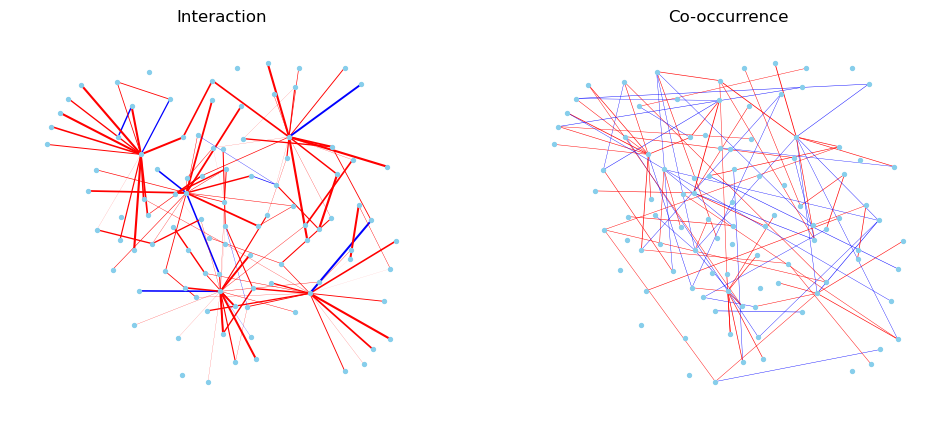

In [5]:
# Plot original and co-occurrence networks side by side for one example
network_hub_plot, G_hub_plot = run_cooccurrence.get_coocc_network(
    interactionMx=hubMxL[0], 
    cutoff=None,
    alpha=alpha, 
    spsamplesize=samplesize, 
    numtrials=numtrials, 
    b=b_L[0], 
    tmax=100, 
    plotNetworks=True, 
    pval_alpha=pval_alpha
)

import pickle, os
os.makedirs('figure_data', exist_ok=True)
import networkx as nx
with open('figure_data/rh_network_plot.pkl', 'wb') as f:
    pickle.dump({
        'network_hub_plot': network_hub_plot,
        'hubMx_input': hubMxL[0],
    }, f)

4. ROC curve for whether NX centrality is a good predictor of whether a node is a hub taxon.

{'degree': 0.9994815789473684,
 'betweenness': 0.9888026315789473,
 'closeness': 0.8342736842105263,
 'eigenvector': 0.8984421052631579}

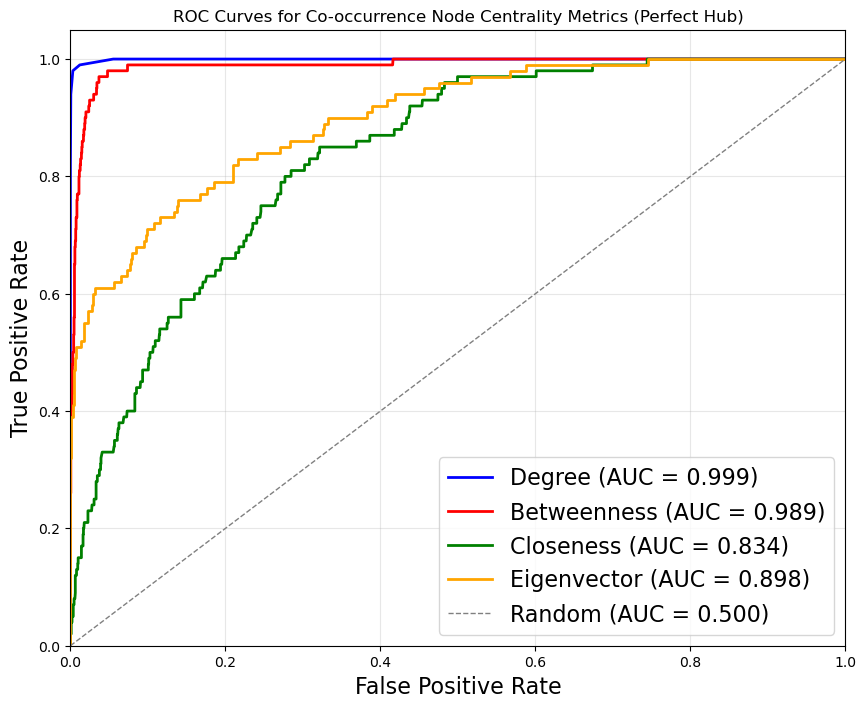

In [6]:
# ROC curve for classifying nodes as hubs
# Using networks generated with get_coocc_network (pval_alpha set at the top)

# get actual hub status
binary_hub_perf = (hubMx_perf != 0).astype(int)
G_actual = nx.from_numpy_array(binary_hub_perf)

degrees = dict(G_actual.degree())
degree_threshold = 2
hub_status = np.array([1 if degrees[node] > degree_threshold else 0 for node in G_actual.nodes()])
assert(np.sum(hub_status) == nModules)

# Calculate centrality metrics using the pre-calculated networks
centrality_metrics = {}
for i in range(n_matrices):
    G_hub_perf_coocc = nx.from_numpy_array(network_hub_perfL[i])
    nodes_ordered = list(G_hub_perf_coocc.nodes())
    assert(np.all(nodes_ordered == list(G_actual.nodes())))

    # add the new centrality metrics to the arrays in the dictionary for this iteration
    centrality_metrics = metrics_and_plotting.calculate_centrality_metrics(G_hub_perf_coocc, nodes_ordered, centrality_metrics)

# plot ROC curves
all_hub_status = np.tile(hub_status, reps = n_matrices)

with open('figure_data/rh_hub_roc_simple.pkl', 'wb') as f:
    pickle.dump({
        'centrality_metrics': centrality_metrics,
        'all_hub_status': all_hub_status,
        'hub_status': hub_status,
        'title': f'ROC Curves for Co-occurrence Node Centrality Metrics (Perfect Hub)',
    }, f)

metrics_and_plotting.plot_hub_roc(centrality_metrics, all_hub_status, title=f'ROC Curves for Co-occurrence Node Centrality Metrics (Perfect Hub)')

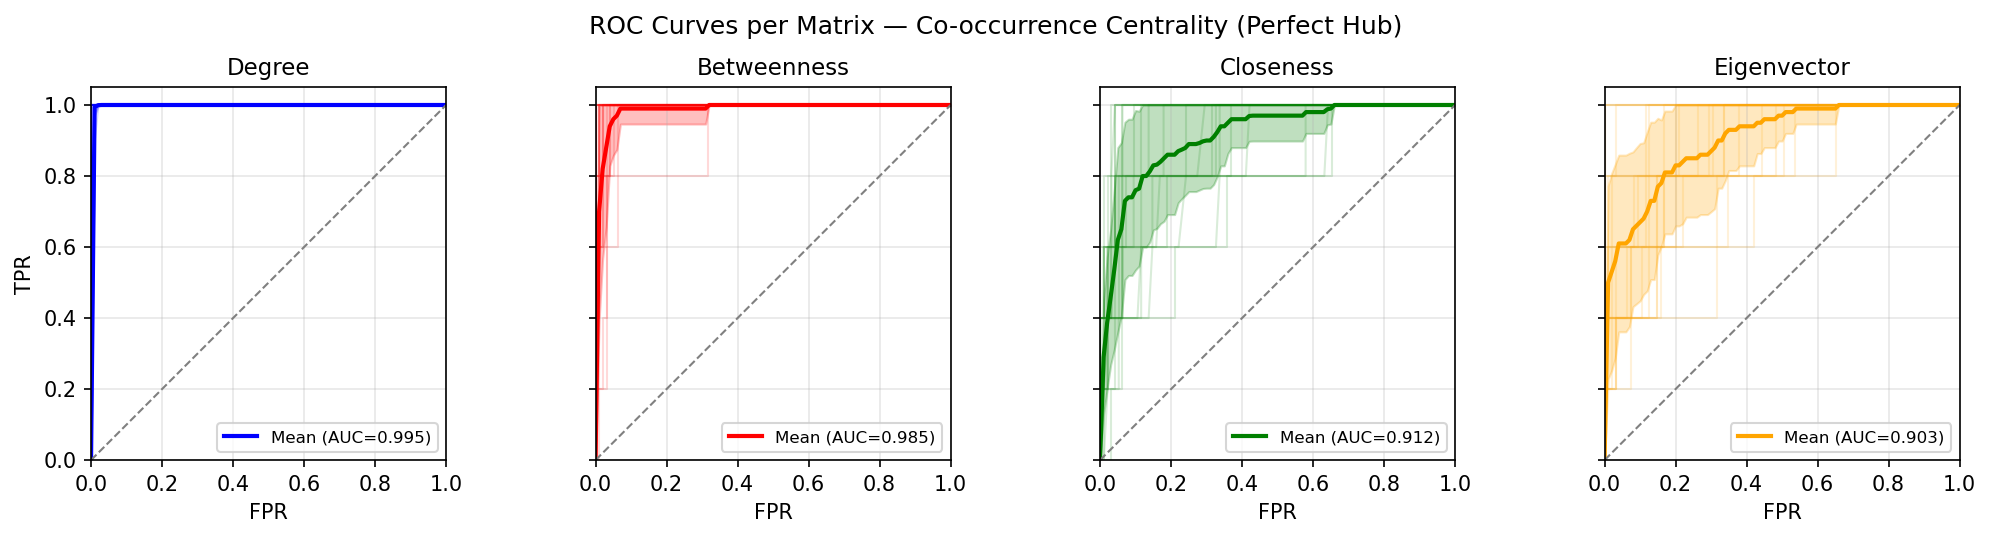

In [7]:
# ROC with individual curves + mean CI (Perfect Hub)
base_fpr = np.linspace(0, 1, 101)
metric_names = ['degree', 'betweenness', 'closeness', 'eigenvector']
colors = ['blue', 'red', 'green', 'orange']

tprs_per_metric = {m: [] for m in metric_names}

for i, (metric_name, color) in enumerate(zip(metric_names, colors)):
    for j in range(n_matrices):
        G_coocc = nx.from_numpy_array(network_hub_perfL[j])
        nodes_ordered = list(G_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_status, cent[metric_name])
        tpr_interp = np.interp(base_fpr, fpr_j, tpr_j)
        tpr_interp[0] = 0.0
        tprs_per_metric[metric_name].append(tpr_interp)

with open('figure_data/rh_roc_perfect.pkl', 'wb') as f:
    pickle.dump({
        'tprs_per_metric': tprs_per_metric,
        'base_fpr': base_fpr,
        'hub_status': hub_status,
        'n_matrices': n_matrices,
        'metric_names': metric_names,
        'colors': colors,
    }, f)

fig, axes = plt.subplots(1, len(metric_names), figsize=(14, 3.5), dpi=150, sharey=True)

for i, (ax, metric_name, color) in enumerate(zip(axes, metric_names, colors)):
    for j in range(n_matrices):
        G_coocc = nx.from_numpy_array(network_hub_perfL[j])
        nodes_ordered = list(G_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_status, cent[metric_name])
        ax.plot(fpr_j, tpr_j, color=color, alpha=0.15, lw=1)

    tprs_arr = np.array(tprs_per_metric[metric_name])
    mean_tpr = tprs_arr.mean(axis=0)
    std_tpr = tprs_arr.std(axis=0)
    mean_auc = metrics.auc(base_fpr, mean_tpr)

    ax.plot(base_fpr, mean_tpr, color=color, lw=2, label=f'Mean (AUC={mean_auc:.3f})')
    ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                    color=color, alpha=0.25)
    ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
    ax.set_title(metric_name.title(), fontsize=11)
    ax.set_xlabel('FPR', fontsize=10)
    if i == 0:
        ax.set_ylabel('TPR', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('ROC Curves per Matrix — Co-occurrence Centrality (Perfect Hub)', fontsize=12)
plt.tight_layout()
plt.show()

{'degree': 0.9958236842105264,
 'betweenness': 0.9838105263157895,
 'closeness': 0.8623631578947368,
 'eigenvector': 0.9037842105263159}

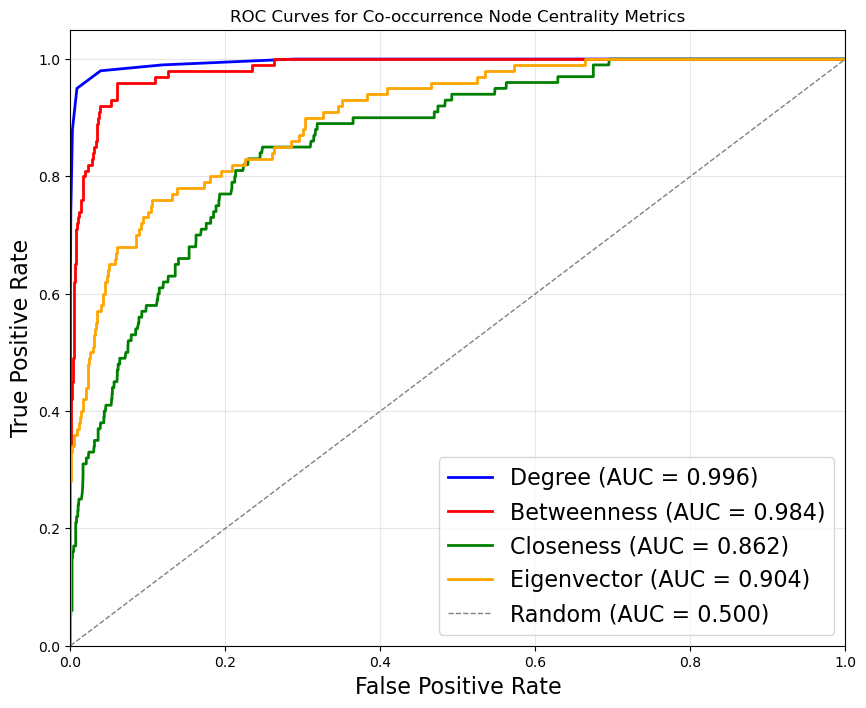

In [8]:
# ROC curve for classifying nodes as hubs for the less perfect hubs
# Using networks generated with get_coocc_network (pval_alpha set at the top)

# get actual hub status
binary_hub = (hubMxL[0] != 0).astype(int)
G_actual = nx.from_numpy_array(binary_hub)

degrees = dict(G_actual.degree())
degree_threshold = 13
hub_status = np.array([1 if degrees[node] > degree_threshold else 0 for node in G_actual.nodes()])
assert(np.sum(hub_status) == nModules)

# Calculate centrality metrics
centrality_metrics = {}
for i in range(n_matrices):
    G_hub_coocc = nx.from_numpy_array(network_hubL[i])
    nodes_ordered = list(G_hub_coocc.nodes())
    assert(np.all(nodes_ordered == list(G_actual.nodes())))

    # add the new centrality metrics to the arrays in the dictionary for this iteration
    centrality_metrics = metrics_and_plotting.calculate_centrality_metrics(G_hub_coocc, nodes_ordered, centrality_metrics)

# plot ROC curves
all_hub_status = np.tile(hub_status, reps = n_matrices)

with open('figure_data/rh_hub_roc_simple_imperfect.pkl', 'wb') as f:
    pickle.dump({
        'centrality_metrics': centrality_metrics,
        'all_hub_status': all_hub_status,
        'hub_status': hub_status,
        'title': f'ROC Curves for Co-occurrence Node Centrality Metrics',
    }, f)

metrics_and_plotting.plot_hub_roc(centrality_metrics, all_hub_status, title=f'ROC Curves for Co-occurrence Node Centrality Metrics')

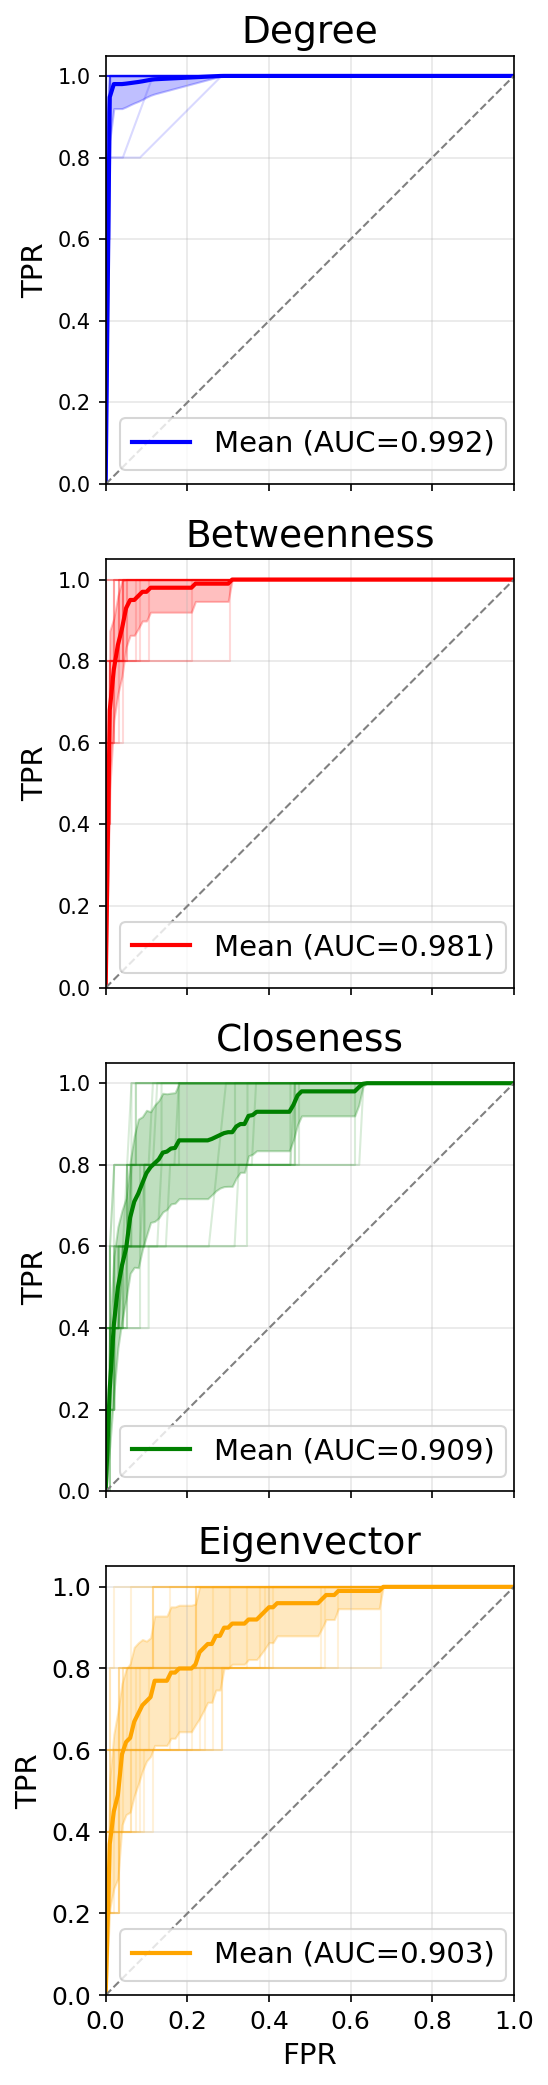

In [9]:
# ROC with individual curves + mean CI (Imperfect Hub)
base_fpr = np.linspace(0, 1, 101)
metric_names = ['degree', 'betweenness', 'closeness', 'eigenvector']
colors = ['blue', 'red', 'green', 'orange']

tprs_per_metric = {m: [] for m in metric_names}

for i, (metric_name, color) in enumerate(zip(metric_names, colors)):
    for j in range(n_matrices):
        G_coocc = nx.from_numpy_array(network_hubL[j])
        nodes_ordered = list(G_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_status, cent[metric_name])
        tpr_interp = np.interp(base_fpr, fpr_j, tpr_j)
        tpr_interp[0] = 0.0
        tprs_per_metric[metric_name].append(tpr_interp)

with open('figure_data/rh_roc_imperfect.pkl', 'wb') as f:
    pickle.dump({
        'tprs_per_metric': tprs_per_metric,
        'base_fpr': base_fpr,
        'hub_status': hub_status,
        'n_matrices': n_matrices,
        'metric_names': metric_names,
        'colors': colors,
    }, f)

fig, axes = plt.subplots(len(metric_names), 1, figsize=(5, 14), dpi=150, sharex=True)

for i, (ax, metric_name, color) in enumerate(zip(axes, metric_names, colors)):
    for j in range(n_matrices):
        G_coocc = nx.from_numpy_array(network_hubL[j])
        nodes_ordered = list(G_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_status, cent[metric_name])
        ax.plot(fpr_j, tpr_j, color=color, alpha=0.15, lw=1)

    tprs_arr = np.array(tprs_per_metric[metric_name])
    mean_tpr = tprs_arr.mean(axis=0)
    std_tpr = tprs_arr.std(axis=0)
    mean_auc = metrics.auc(base_fpr, mean_tpr)

    ax.plot(base_fpr, mean_tpr, color=color, lw=2, label=f'Mean (AUC={mean_auc:.3f})')
    ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                    color=color, alpha=0.25)
    ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
    ax.set_title(metric_name.title(), fontsize=18)
    ax.set_ylabel('TPR', fontsize=14)
    if i == len(metric_names) - 1:
        ax.set_xlabel('FPR', fontsize=14)
    ax.legend(fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

In [10]:
n_matrices = 30
pBetweenModL = [0, 0.001, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.3, 0.4]
pHub = 1
p_interact_nonhub = [None for i in range(len(pBetweenModL))]

b_L = [np.ones(nSpec) - np.random.uniform(low=0, high=0.1, size=(nSpec)) 
       for i in range(n_matrices)]

# per-matrix AUC lists: shape (len(pBetweenModL), n_matrices)
AUC_deg_L = [[] for _ in range(len(pBetweenModL))]
AUC_betweenness_L = [[] for _ in range(len(pBetweenModL))]
AUC_closeness_L = [[] for _ in range(len(pBetweenModL))]
AUC_eigenvector_L = [[] for _ in range(len(pBetweenModL))]
AUC_directEdge_L = [[] for _ in range(len(pBetweenModL))]

## making AUC vs %interactions outside hub
for ii in range(len(pBetweenModL)):
    pBetweenMod = pBetweenModL[ii]
    pWithinMod = pBetweenMod
    print(pBetweenMod)
    hubMxL = [metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = pBetweenMod, nModules = nModules, pHub = pHub)
                for i in range(n_matrices)]

    network_hubL = list()
    hubMxL_bin = list()

    for i in range(n_matrices):
        network_hub, G_hub = run_cooccurrence.get_coocc_network(
            interactionMx=hubMxL[i], 
            cutoff=None,
            alpha=alpha, 
            spsamplesize=samplesize, 
            numtrials=numtrials, 
            b=b_L[i], 
            tmax=100, 
            plotNetworks=False, 
            pval_alpha=pval_alpha,
            max_step=1.0
        )
        network_hubL.append(network_hub)
        hubMxL_bin.append(hubMxL[i] != 0)

    # get actual hub status
    binary_hub = (hubMxL[0] != 0).astype(int)
    G_actual = nx.from_numpy_array(binary_hub)
    degrees = dict(G_actual.degree())
    top_5_nodes = set(sorted(G_actual.nodes(), key=lambda node: degrees[node], reverse=True)[:5])
    hub_status = np.array([1 if node in top_5_nodes else 0 for node in G_actual.nodes()])
    print(f"max node degree: {max([d for n,d in G_actual.degree])}")

    graph_nohub = G_actual.copy()
    for node in top_5_nodes:
        graph_nohub.remove_node(node)
    p_interact_nonhub[ii] = (sum([d for n,d in graph_nohub.degree()])) / (graph_nohub.number_of_nodes()**2 - graph_nohub.number_of_nodes())

    # compute per-matrix AUC
    for i in range(n_matrices):
        G_hub_coocc = nx.from_numpy_array(network_hubL[i])
        nodes_ordered = list(G_hub_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_hub_coocc, nodes_ordered, {})

        for metric_name, auc_list in [('degree', AUC_deg_L), ('betweenness', AUC_betweenness_L),
                                       ('closeness', AUC_closeness_L), ('eigenvector', AUC_eigenvector_L)]:
            fpr, tpr, _ = metrics.roc_curve(hub_status, cent[metric_name])
            auc_list[ii].append(metrics.auc(fpr, tpr))

        # direct edge AUC per matrix
        edge_flat = hubMxL_bin[i][np.triu_indices(nSpec, k=1)].astype(int)
        corr_flat = np.abs(network_hubL[i][np.triu_indices(nSpec, k=1)])
        fpr_d, tpr_d, _ = metrics.roc_curve(edge_flat, corr_flat)
        AUC_directEdge_L[ii].append(metrics.auc(fpr_d, tpr_d))

0
max node degree: 19
0.001
max node degree: 19
0.01
max node degree: 22
0.02
max node degree: 25
0.03
max node degree: 24
0.04
max node degree: 28
0.05
max node degree: 33
0.06
max node degree: 30
0.07
max node degree: 32
0.08
max node degree: 30
0.09
max node degree: 38
0.1
max node degree: 36
0.12
max node degree: 41
0.14
max node degree: 46
0.16
max node degree: 46
0.18
max node degree: 54
0.2
max node degree: 56
0.3
max node degree: 66
0.4
max node degree: 77


In [11]:
with open('figure_data/rh_hub_auc.pkl', 'wb') as f:
    pickle.dump({
        'p_interact_nonhub': p_interact_nonhub,
        'AUC_deg_L': AUC_deg_L,
        'AUC_betweenness_L': AUC_betweenness_L,
        'AUC_closeness_L': AUC_closeness_L,
        'AUC_eigenvector_L': AUC_eigenvector_L,
        'AUC_directEdge_L': AUC_directEdge_L,
    }, f)

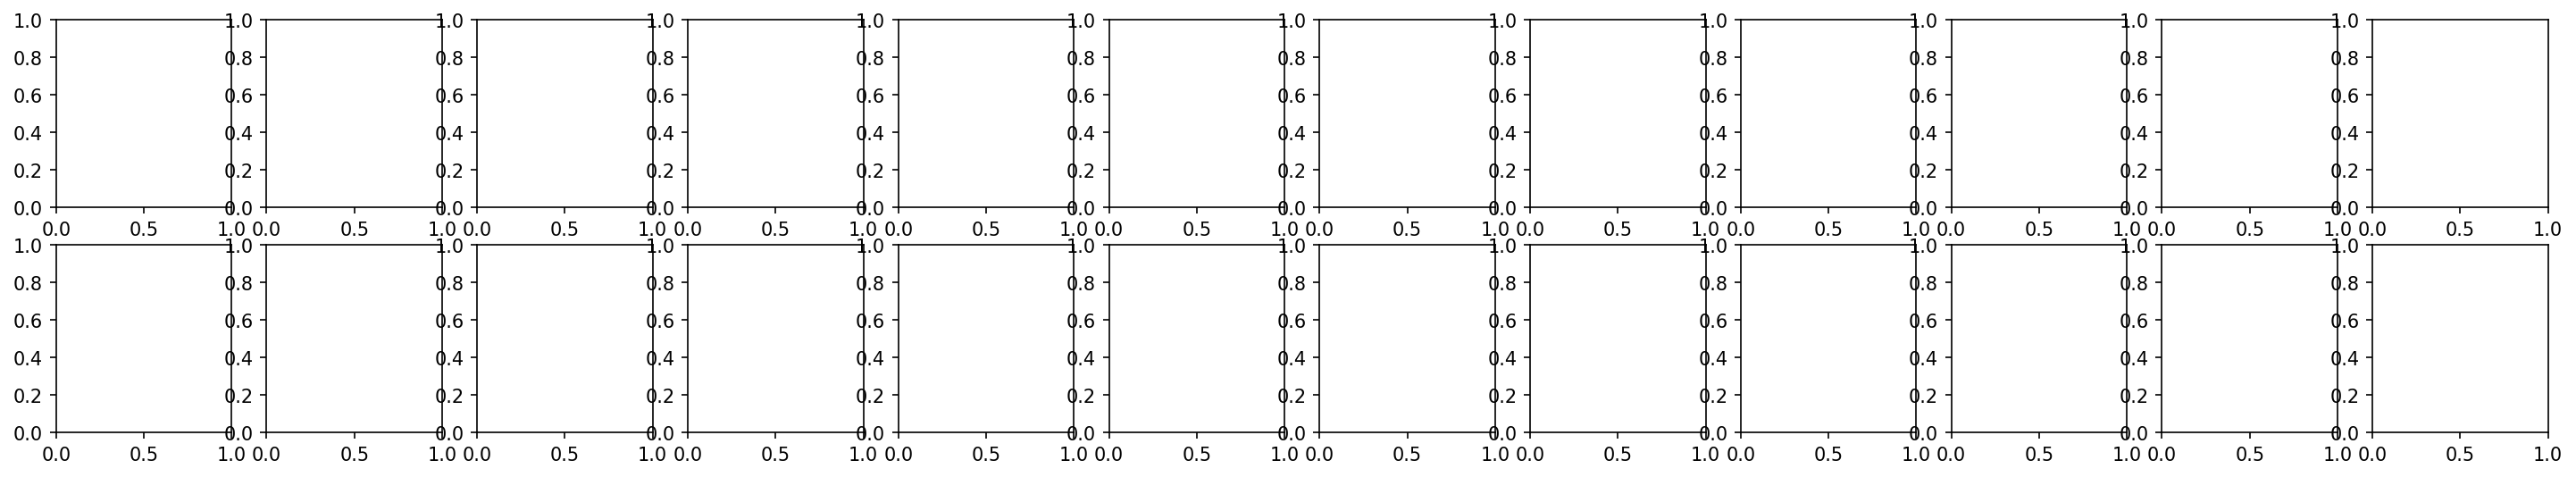

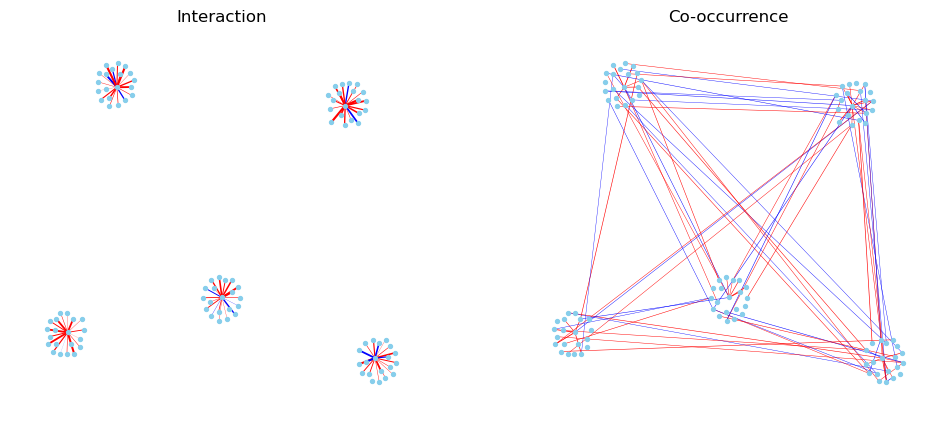

p=0: [19, 19, 19, 19, 19, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


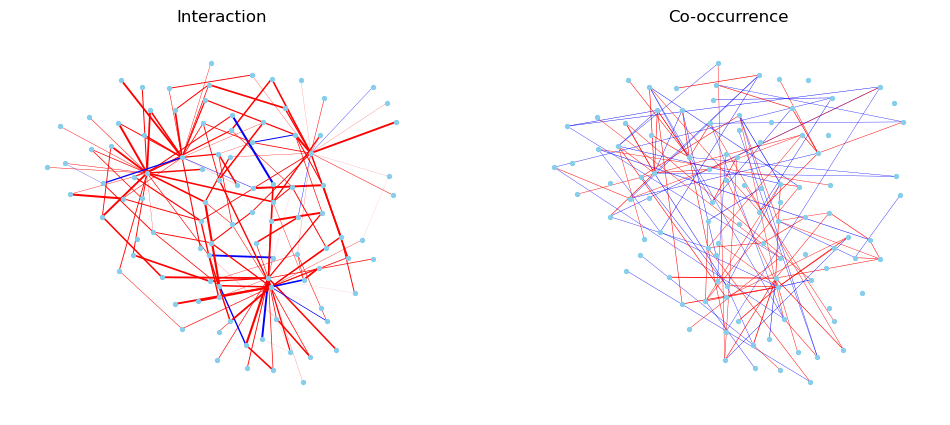

p=0.01: [21, 21, 21, 20, 19, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1]


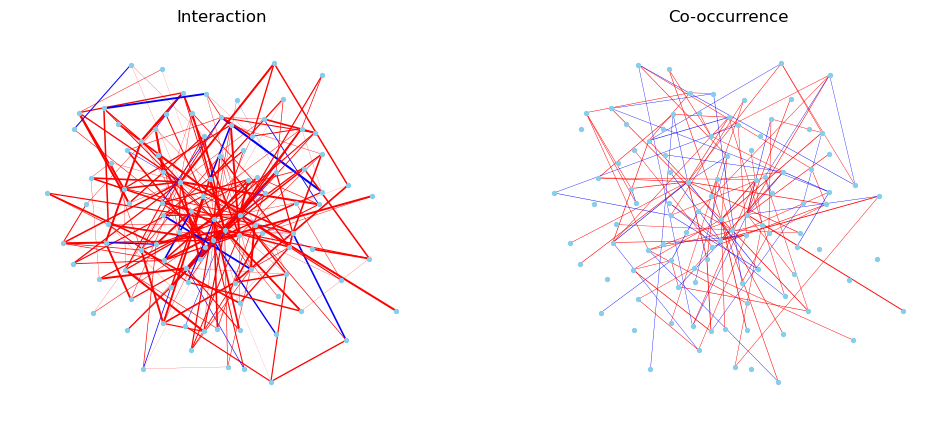

p=0.03: [28, 26, 26, 24, 23, 13, 12, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 2]


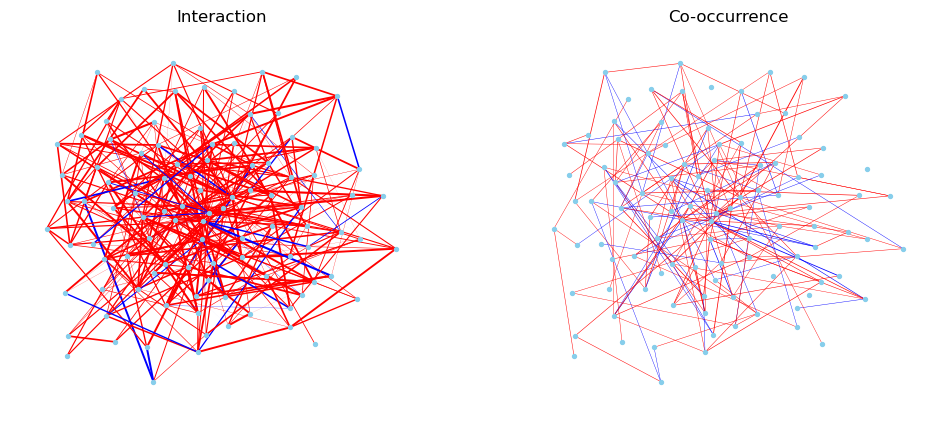

p=0.05: [33, 30, 27, 26, 26, 20, 18, 18, 17, 16, 16, 16, 16, 16, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 6, 6, 6, 5, 5, 4, 4]


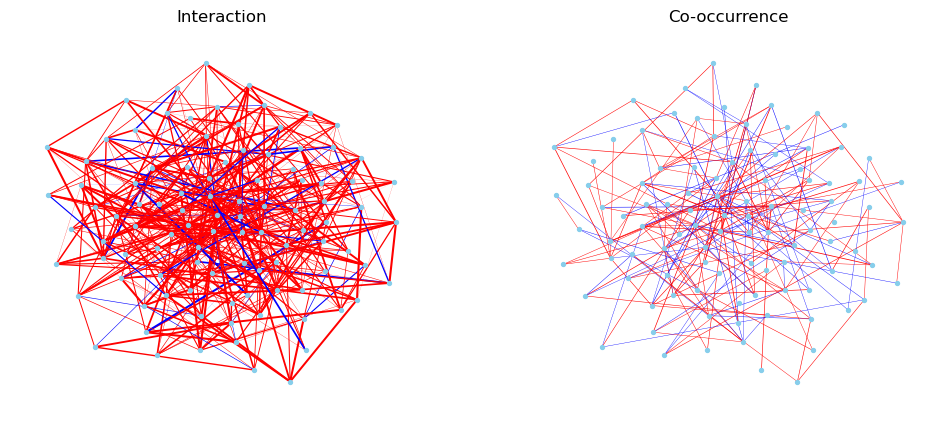

p=0.07: [33, 31, 28, 28, 27, 23, 23, 21, 21, 21, 20, 20, 20, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 8]


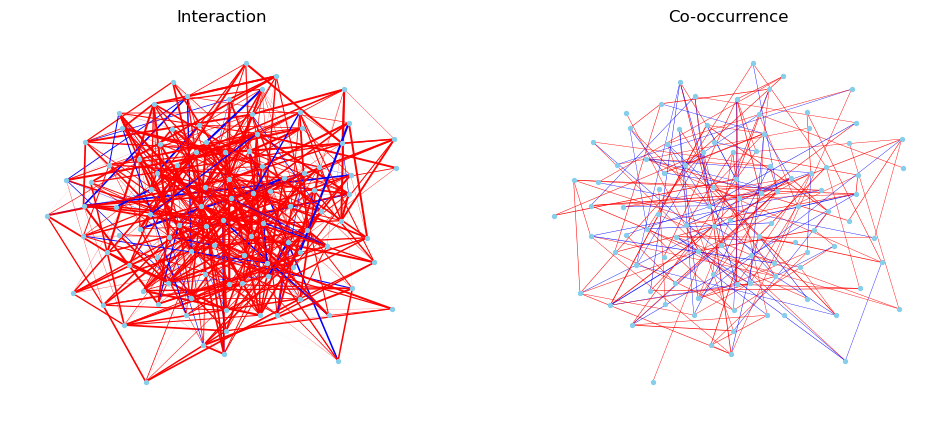

p=0.09: [38, 34, 31, 31, 30, 25, 24, 24, 23, 23, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 21, 21, 21, 21, 21, 21, 21, 20, 20, 20, 20, 20, 20, 19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 11, 11, 11, 11, 9]


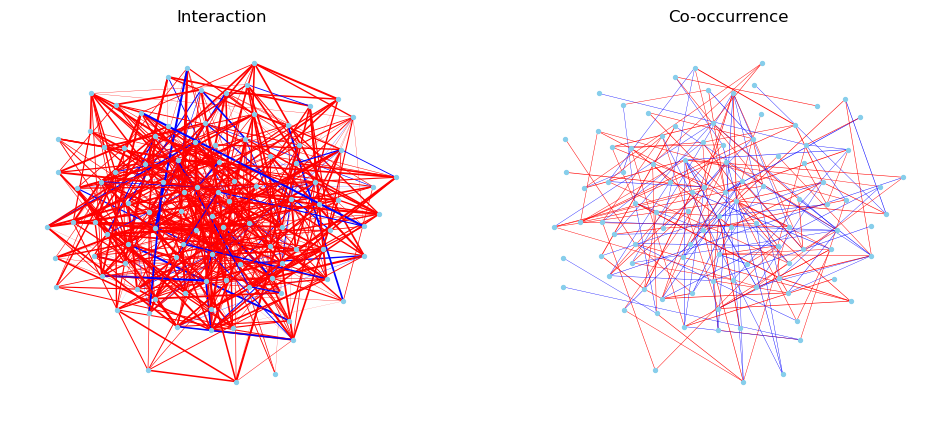

p=0.1: [40, 39, 37, 36, 31, 29, 28, 28, 28, 27, 26, 26, 26, 26, 26, 25, 25, 25, 24, 24, 24, 24, 24, 23, 23, 23, 23, 23, 22, 22, 22, 21, 21, 21, 21, 21, 21, 21, 21, 21, 20, 20, 20, 20, 20, 20, 20, 20, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 12, 12, 9]


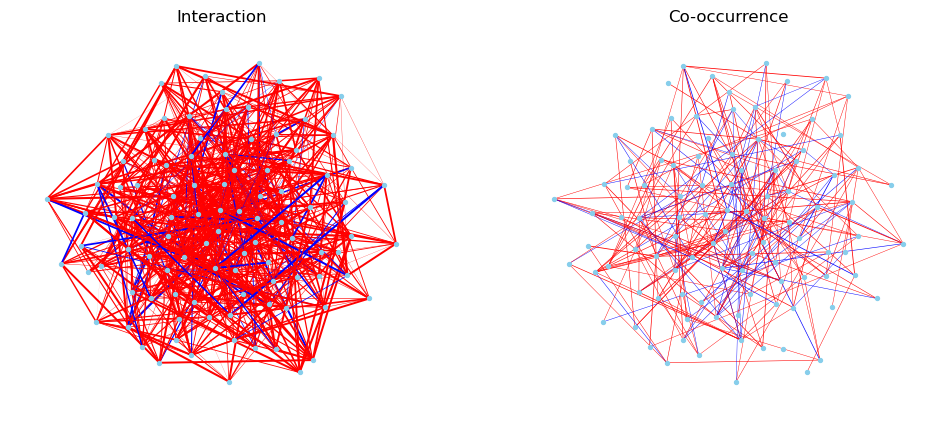

p=0.14: [46, 46, 42, 41, 39, 39, 38, 36, 35, 34, 34, 33, 32, 32, 32, 32, 32, 32, 31, 31, 31, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 29, 29, 29, 29, 29, 28, 28, 28, 28, 28, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 25, 25, 25, 25, 24, 24, 24, 24, 23, 23, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 21, 21, 21, 21, 20, 20, 20, 19, 19, 19, 19, 18, 17, 16]


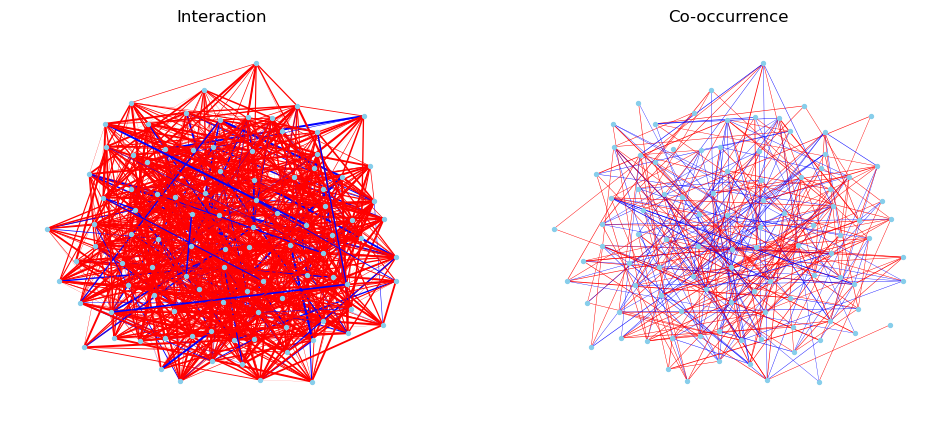

p=0.18: [52, 49, 45, 44, 42, 41, 41, 41, 40, 40, 39, 39, 39, 39, 38, 38, 38, 37, 37, 37, 37, 37, 37, 37, 37, 37, 36, 36, 36, 36, 36, 36, 36, 35, 35, 35, 35, 35, 35, 35, 35, 35, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 33, 33, 33, 33, 33, 33, 33, 33, 33, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 30, 30, 29, 28, 28, 28, 28, 28, 28, 28, 26, 26, 25, 24, 22]


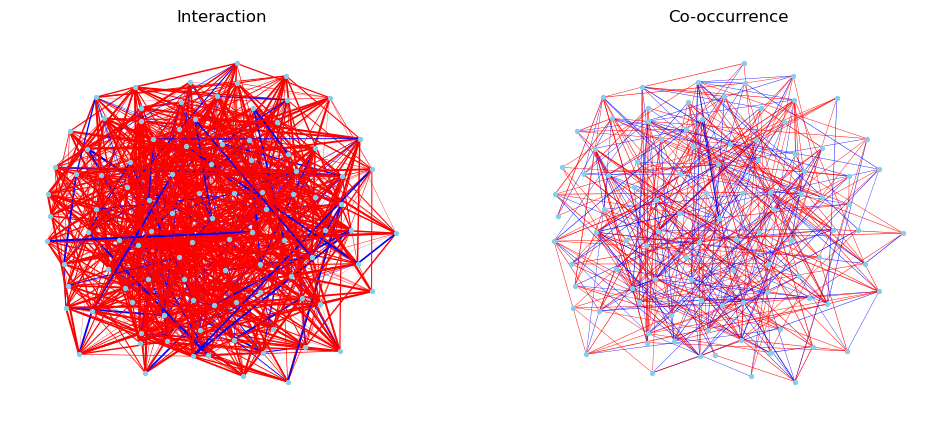

p=0.2: [49, 49, 46, 46, 45, 45, 44, 44, 43, 43, 43, 43, 43, 42, 42, 42, 42, 42, 41, 41, 41, 41, 41, 41, 41, 40, 40, 40, 40, 40, 39, 39, 39, 39, 39, 38, 38, 38, 38, 38, 38, 38, 38, 37, 37, 37, 37, 37, 37, 37, 36, 36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 34, 34, 34, 34, 34, 34, 33, 33, 33, 33, 33, 33, 33, 33, 33, 32, 32, 32, 31, 31, 31, 31, 30, 30, 30, 28, 28, 27, 26]


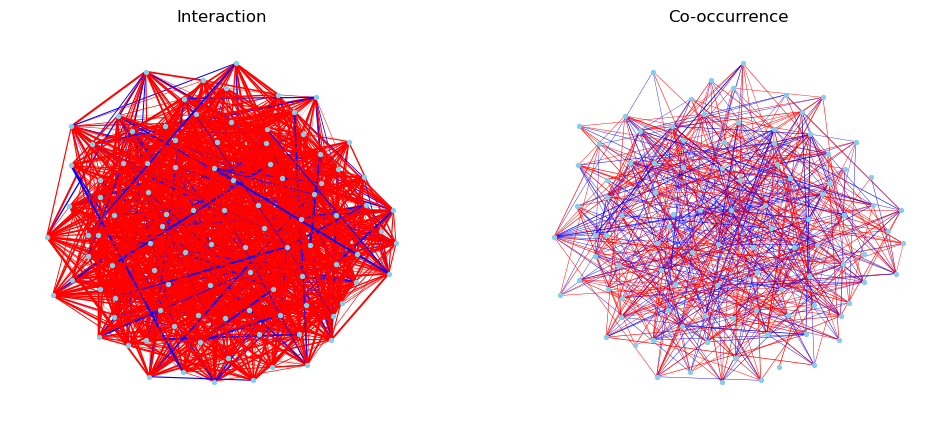

p=0.3: [63, 62, 62, 62, 61, 60, 60, 59, 58, 57, 57, 57, 57, 56, 56, 56, 55, 55, 55, 55, 55, 54, 54, 54, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 52, 52, 52, 52, 52, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 49, 49, 49, 49, 49, 49, 49, 49, 49, 49, 49, 49, 49, 48, 48, 48, 47, 47, 47, 47, 46, 46, 46, 46, 45, 45, 44, 44, 43, 43, 43, 42, 42, 41]


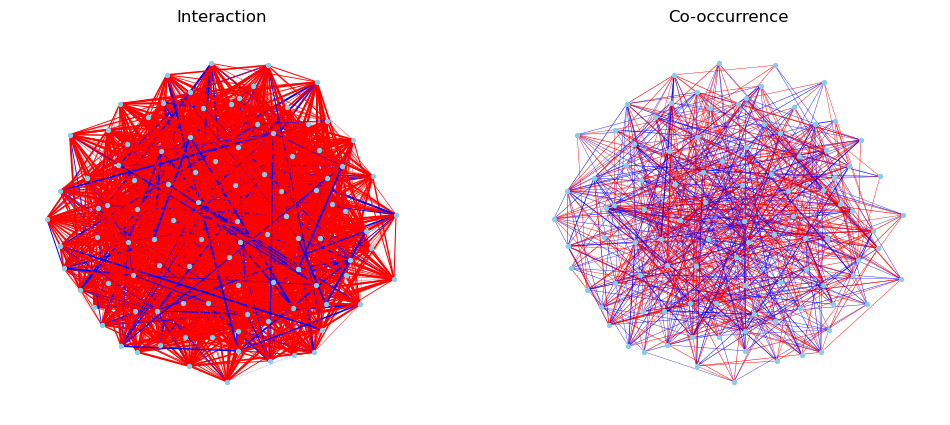

p=0.4: [76, 75, 75, 74, 73, 73, 72, 72, 71, 71, 71, 70, 70, 70, 70, 70, 70, 69, 69, 69, 69, 69, 69, 69, 68, 68, 68, 68, 68, 68, 68, 67, 67, 67, 67, 67, 67, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 65, 65, 65, 65, 65, 65, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 63, 63, 63, 63, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 61, 61, 60, 60, 60, 60, 60, 60, 60, 59, 59, 59, 58, 58, 57, 57, 57, 56, 54, 54, 54, 50]


<Figure size 640x480 with 0 Axes>

In [12]:
pBetweenModL = [0, 0.01, 0.03, 0.05, 0.07, 0.09, 0.1, 0.14, 0.18, 0.2, 0.3, 0.4]
n_matrices=5
# ROC curves for degree centrality + degree distribution, one column per pBetweenMod value

_roc_pBetween_data = []
base_fpr = np.linspace(0, 1, 101)
ncols = len(pBetweenModL)
fig, axes = plt.subplots(2, ncols, figsize=(24, 4), dpi=150)
# layout: row 0 = ROC (ii 0-6), row 1 = degree dist (ii 0-6)
#         row 2 = ROC (ii 7-13), row 3 = degree dist (ii 7-13)

for ii, pBetweenMod in enumerate(pBetweenModL):
    col = ii
    roc_row = 0
    deg_row = 1
    ax_roc = axes[roc_row, col]
    ax_deg = axes[deg_row, col]

    pWithinMod = pBetweenMod
    hubMxL_ii = [metaCommunityMx.generateHubMatrix(maxInteractionStrength=interactStren, pPositive=pPositive,
                  nSpecies=nSpec, pWithinMod=pWithinMod, pBetweenMod=pBetweenMod,
                  nModules=nModules, pHub=pHub) for _ in range(n_matrices)]

    network_hubL_ii = []
    for i in range(n_matrices):
        if i == 0:
            pos_ii = nx.spring_layout(nx.from_numpy_array(hubMxL_ii[0] != 0), seed=42)
            net, _, pearson_ii = run_cooccurrence.get_coocc_network(
                interactionMx=hubMxL_ii[i], cutoff=None, alpha=alpha,
                spsamplesize=samplesize, numtrials=numtrials, b=b_L[i],
                tmax=100, plotNetworks=True, pval_alpha=pval_alpha, max_step=1.0,
                pos=pos_ii, return_pearson=True)
            with open(f'figure_data/rh_network_pBetween{pBetweenMod}.pkl', 'wb') as f:
                pickle.dump({
                    'interactionMx': hubMxL_ii[0],
                    'network_coocc': net,
                    'pearson_corr': pearson_ii,
                    'pos': pos_ii,
                    'pBetweenMod': pBetweenMod,
                }, f)
        else:
            net, _ = run_cooccurrence.get_coocc_network(
                interactionMx=hubMxL_ii[i], cutoff=None, alpha=alpha,
                spsamplesize=samplesize, numtrials=numtrials, b=b_L[i],
                tmax=100, plotNetworks=False, pval_alpha=pval_alpha, max_step=1.0)
        network_hubL_ii.append(net)

    binary_hub = (hubMxL_ii[0] != 0).astype(int)
    G_actual = nx.from_numpy_array(binary_hub)
    degrees_ii = dict(G_actual.degree())
    top_5 = set(sorted(G_actual.nodes(), key=lambda n: degrees_ii[n], reverse=True)[:5])
    hub_status_ii = np.array([1 if n in top_5 else 0 for n in G_actual.nodes()])

    # --- ROC subplot ---
    tprs = []
    for i in range(n_matrices):
        G_coocc = nx.from_numpy_array(network_hubL_ii[i])
        nodes_ordered = list(G_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_coocc, nodes_ordered, {})
        fpr_i, tpr_i, _ = metrics.roc_curve(hub_status_ii, cent['degree'])
        ax_roc.plot(fpr_i, tpr_i, color='blue', alpha=0.15, lw=1)
        tpr_interp = np.interp(base_fpr, fpr_i, tpr_i)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    tprs = np.array(tprs)
    _deg_hub = [degrees_ii[n] for n in top_5]
    _deg_nonhub = [d for n, d in G_actual.degree() if n not in top_5]
    _roc_pBetween_data.append({
        'pBetweenMod': pBetweenMod,
        'tprs_arr': tprs,
        'hub_degrees': _deg_hub,
        'nonhub_degrees': _deg_nonhub,
        'hub_status': hub_status_ii,
    })
    mean_tpr = tprs.mean(axis=0)
    std_tpr = tprs.std(axis=0)
    mean_auc = metrics.auc(base_fpr, mean_tpr)

    ax_roc.plot(base_fpr, mean_tpr, color='blue', lw=2, label=f'AUC={mean_auc:.2f}')
    ax_roc.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                        color='blue', alpha=0.25)
    ax_roc.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
    ax_roc.set_title(f'p={pBetweenMod}', fontsize=7)
    ax_roc.legend(fontsize=6, loc='lower right')
    ax_roc.set_aspect('equal')
    ax_roc.grid(True, alpha=0.3)
    ax_roc.tick_params(labelsize=6)

    # --- Degree distribution subplot (actual interaction network, run 0) ---
    deg_seq = sorted([d for _, d in G_actual.degree()], reverse=True)
    hub_degrees = [degrees_ii[n] for n in top_5]
    non_hub_degrees = [d for n, d in G_actual.degree() if n not in top_5]

    ax_deg.hist(non_hub_degrees, bins=15, color='steelblue', alpha=0.7, label='non-hub')
    ax_deg.hist(hub_degrees, bins=5, color='tomato', alpha=0.9, label='hub')
    ax_deg.set_xlabel('degree', fontsize=6)
    ax_deg.tick_params(labelsize=6)
    ax_deg.legend(fontsize=5, loc='upper right')
    ax_deg.grid(True, alpha=0.3)

    # print sorted degree sequence
    print(f"p={pBetweenMod}: {deg_seq}")

with open('figure_data/rh_roc_pBetween.pkl', 'wb') as f:
    pickle.dump({'roc_pBetween_data': _roc_pBetween_data, 'pBetweenModL': pBetweenModL}, f)

# label shared axes
for col in range(ncols):
    axes[0, col].set_xlabel('')
    axes[1, col].set_xlabel('')
axes[0, 0].set_ylabel('TPR', fontsize=7)
axes[1, 0].set_ylabel('count', fontsize=7)

fig.suptitle('Degree Centrality ROC + Degree Distribution per pBetweenMod', fontsize=11)
plt.tight_layout()
plt.show()

(0.47, 1.01)

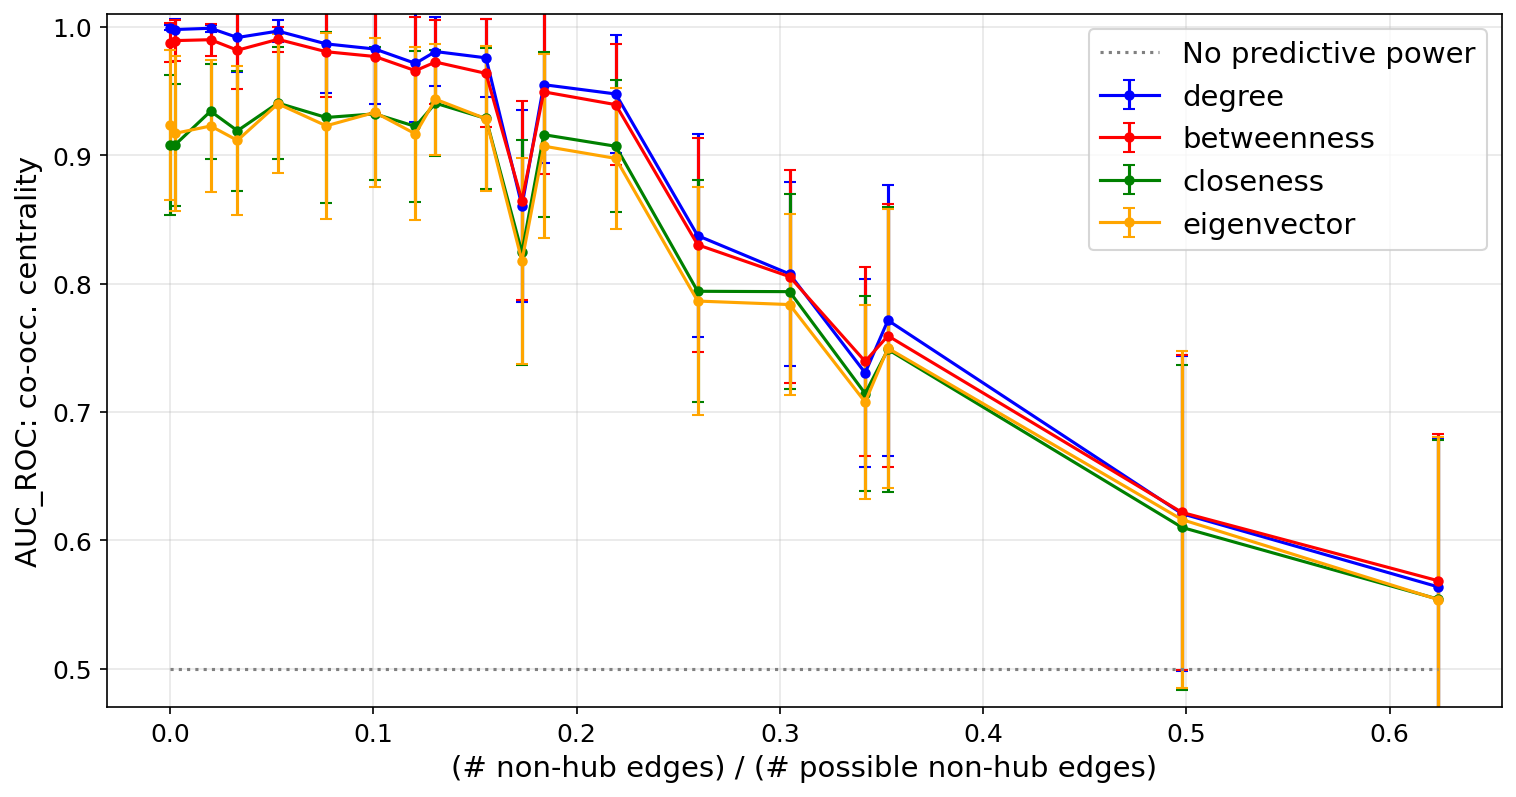

In [13]:
# Plot AUC vs % messed up — mean ± std dev across matrices
plt.figure(figsize=(12, 6), dpi=150)
for auc_data, label, color in [
    (AUC_deg_L, 'degree', 'blue'),
    (AUC_betweenness_L, 'betweenness', 'red'),
    (AUC_closeness_L, 'closeness', 'green'),
    (AUC_eigenvector_L, 'eigenvector', 'orange'),
]:
    means = [np.mean(x) for x in auc_data]
    #sems = [2*(np.std(x) / np.sqrt(len(x))) for x in auc_data]
    stds = [np.std(x) for x in auc_data]
    plt.errorbar(p_interact_nonhub, means, yerr=stds, color=color, label=label,
                 marker='o', markersize=4, capsize=3, lw=1.5)
plt.xlabel('(# non-hub edges) / (# possible non-hub edges)', fontsize=14)
plt.ylabel('AUC_ROC: co-occ. centrality', fontsize=14)
plt.hlines(0.5, xmin=0, xmax=max(p_interact_nonhub), colors="gray", linestyles="dotted", label="No predictive power")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.tick_params(labelsize=12)
plt.ylim(0.47, 1.01)

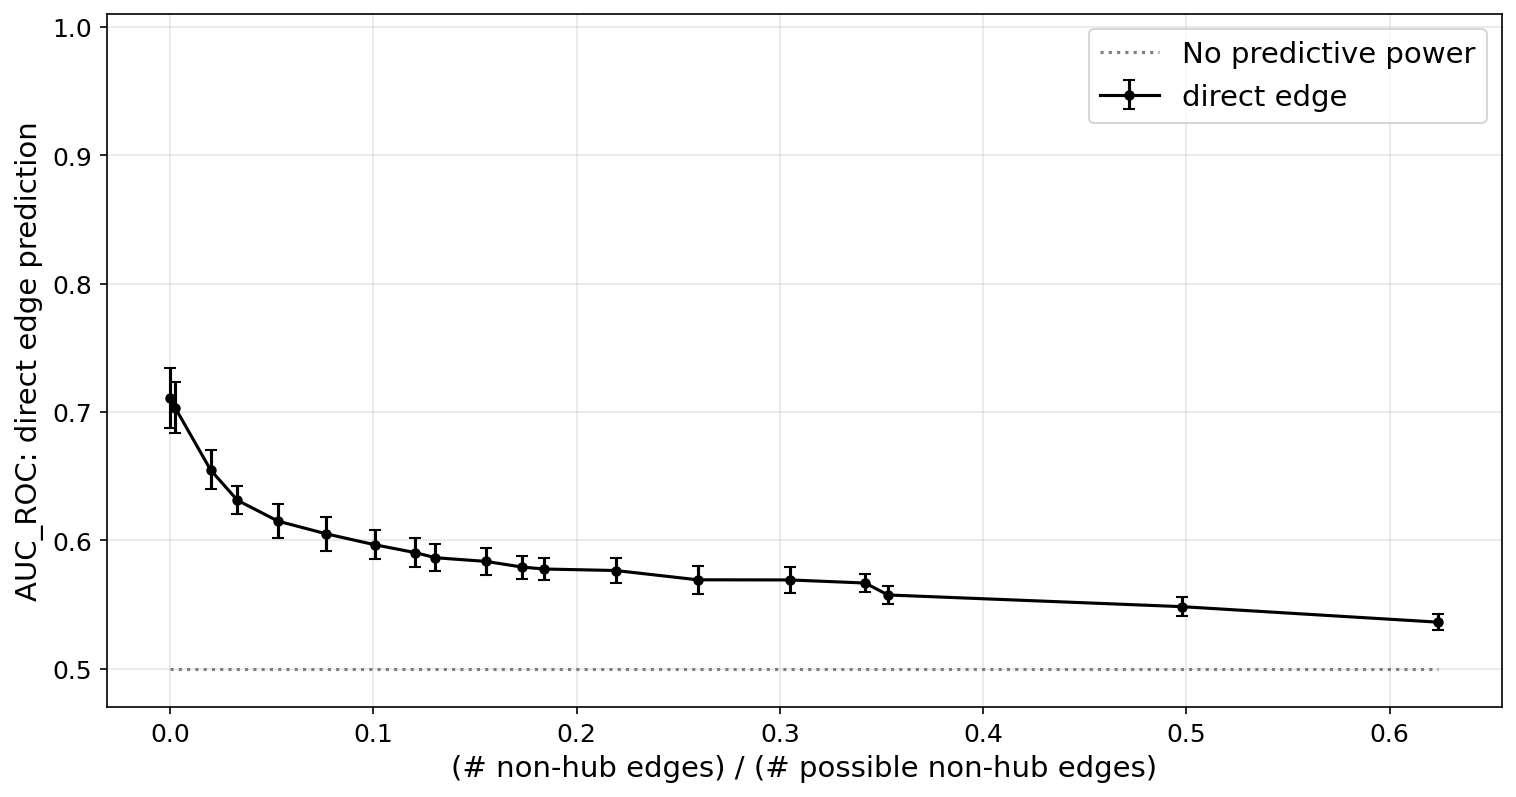

In [14]:
# Plot AUC vs % messed up — mean ± std across matrices (direct edge prediction)
plt.figure(figsize=(12, 6), dpi=150)
means = [np.mean(x) for x in AUC_directEdge_L]
#sems = [2*(np.std(x) / np.sqrt(len(x))) for x in AUC_directEdge_L]
stds = [np.std(x) for x in AUC_directEdge_L]
plt.errorbar(p_interact_nonhub, means, yerr=stds, color="black", label="direct edge",
             marker='o', markersize=4, capsize=3, lw=1.5)
plt.xlabel('(# non-hub edges) / (# possible non-hub edges)', size=14)
plt.ylabel('AUC_ROC: direct edge prediction', size=14)
plt.hlines(0.5, xmin=0, xmax=max(p_interact_nonhub), colors="gray", linestyles="dotted", label="No predictive power")
plt.legend(fontsize = 14)
plt.ylim(0.47, 1.01)
plt.tick_params(labelsize=12)
plt.grid(True, alpha=0.3)

## Compositional analysis (relative abundances)

In [15]:
interactFactor = 1/5
nSpec = 100
nModules = 5
pPositive = 0.1
n_matrices_comp = 20

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor

# confidence set for cutoff
pval_alpha = 0.01

# for less perfect hubs
pWithinMod = 0.01
pBetweenMod = 0.01
pHub = 0.9

b_L_comp = [np.ones(nSpec) - np.random.uniform(low=0, high=0.1, size=(nSpec)) 
       for i in range(n_matrices_comp)]

zeroMx = np.zeros(shape = (nSpec, nSpec))
hubMx_perf_comp = metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = 0, pBetweenMod = 0, nModules = nModules, pHub = 0.9)
hubMxL_comp = [metaCommunityMx.generateHubMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = pBetweenMod, nModules = nModules, pHub = pHub)
            for i in range(n_matrices_comp)]

In [16]:
network_comp_hubL = list()
network_comp_hub_perfL = list()

print("imperfect")
for i in range(n_matrices_comp):
    network_comp_hub, G_comp_hub = run_cooccurrence.get_coocc_network(
        interactionMx=hubMxL_comp[i], 
        cutoff=None,  # calculate null cutoffs
        alpha=alpha, 
        spsamplesize=samplesize, 
        numtrials=numtrials, 
        b=b_L_comp[i], 
        tmax=100, 
        plotNetworks=False, 
        pval_alpha=pval_alpha,
        compositional=True
    )
    network_comp_hubL.append(network_comp_hub)

print("perfect")
for i in range(n_matrices_comp):
    network_comp_hub_perf, G_comp_hub_perf = run_cooccurrence.get_coocc_network(
        interactionMx=hubMx_perf_comp, 
        cutoff=None, 
        alpha=alpha, 
        spsamplesize=samplesize, 
        numtrials=numtrials, 
        b=b_L_comp[i], 
        tmax=100, 
        plotNetworks=False, 
        pval_alpha=pval_alpha,
        compositional=True
    )
    network_comp_hub_perfL.append(network_comp_hub_perf)

imperfect
perfect


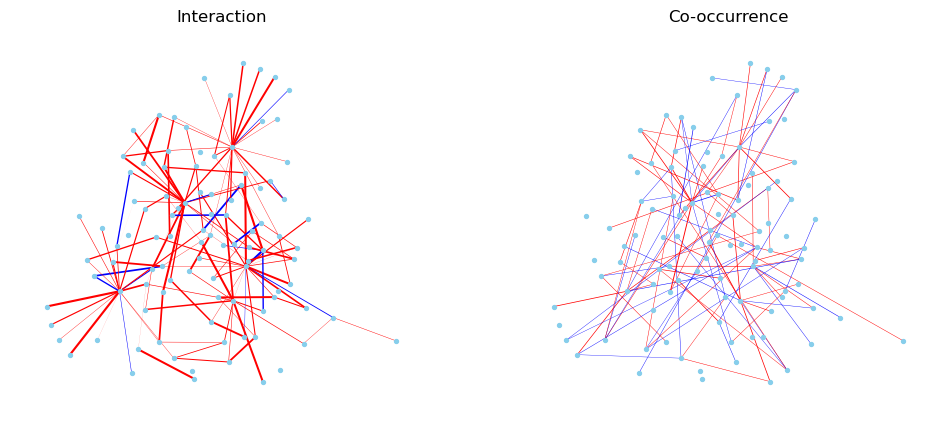

In [17]:
# Plot interaction and co-occurrence networks side by side for one example
network_comp_hub_plot, G_comp_hub_plot = run_cooccurrence.get_coocc_network(
    interactionMx=hubMxL_comp[0], 
    cutoff=None,
    alpha=alpha, 
    spsamplesize=samplesize, 
    numtrials=numtrials, 
    b=b_L_comp[0], 
    tmax=100, 
    plotNetworks=True, 
    pval_alpha=pval_alpha,
    compositional=True
)

import pickle, os
os.makedirs('figure_data', exist_ok=True)
import networkx as nx
with open('figure_data/rh_network_plot_comp.pkl', 'wb') as f:
    pickle.dump({
        'network_comp_hub_plot': network_comp_hub_plot,
        'hubMx_input': hubMxL_comp[0],
    }, f)

{'degree': 0.9885657894736841,
 'betweenness': 0.9674736842105263,
 'closeness': 0.8027947368421052,
 'eigenvector': 0.8544842105263158}

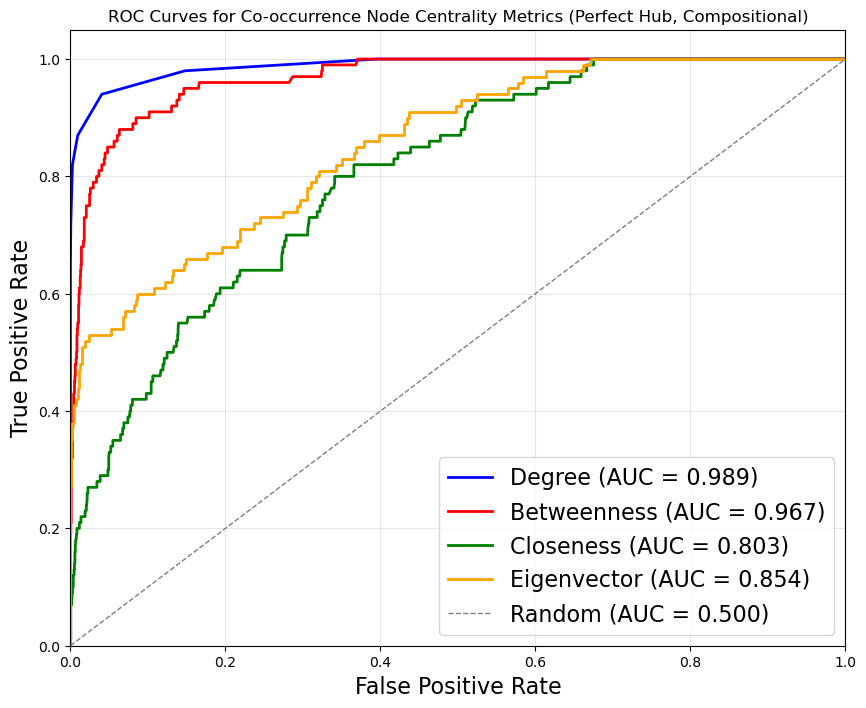

In [18]:
# ROC curve for classifying nodes as hubs
# Using networks generated with get_coocc_network (pval_alpha set at the top)

# get actual hub status
binary_comp_hub_perf = (hubMx_perf_comp != 0).astype(int)
G_comp_actual = nx.from_numpy_array(binary_comp_hub_perf)

degrees = dict(G_comp_actual.degree())
degree_threshold = 2
hub_comp_status = np.array([1 if degrees[node] > degree_threshold else 0 for node in G_comp_actual.nodes()])
assert(np.sum(hub_comp_status) == nModules)

# Calculate centrality metrics using the pre-calculated networks
centrality_comp_metrics = {}
for i in range(n_matrices_comp):
    G_comp_hub_perf_coocc = nx.from_numpy_array(network_comp_hub_perfL[i])
    nodes_ordered = list(G_comp_hub_perf_coocc.nodes())
    assert(np.all(nodes_ordered == list(G_comp_actual.nodes())))

    # add the new centrality metrics to the arrays in the dictionary for this iteration
    centrality_comp_metrics = metrics_and_plotting.calculate_centrality_metrics(G_comp_hub_perf_coocc, nodes_ordered, centrality_comp_metrics)

# plot ROC curves
all_hub_comp_status = np.tile(hub_comp_status, reps = n_matrices_comp)

with open('figure_data/rh_hub_roc_simple_comp.pkl', 'wb') as f:
    pickle.dump({
        'centrality_comp_metrics': centrality_comp_metrics,
        'all_hub_comp_status': all_hub_comp_status,
        'hub_comp_status': hub_comp_status,
        'title': f'ROC Curves for Co-occurrence Node Centrality Metrics (Perfect Hub, Compositional)',
    }, f)

metrics_and_plotting.plot_hub_roc(centrality_comp_metrics, all_hub_comp_status, title=f'ROC Curves for Co-occurrence Node Centrality Metrics (Perfect Hub, Compositional)')

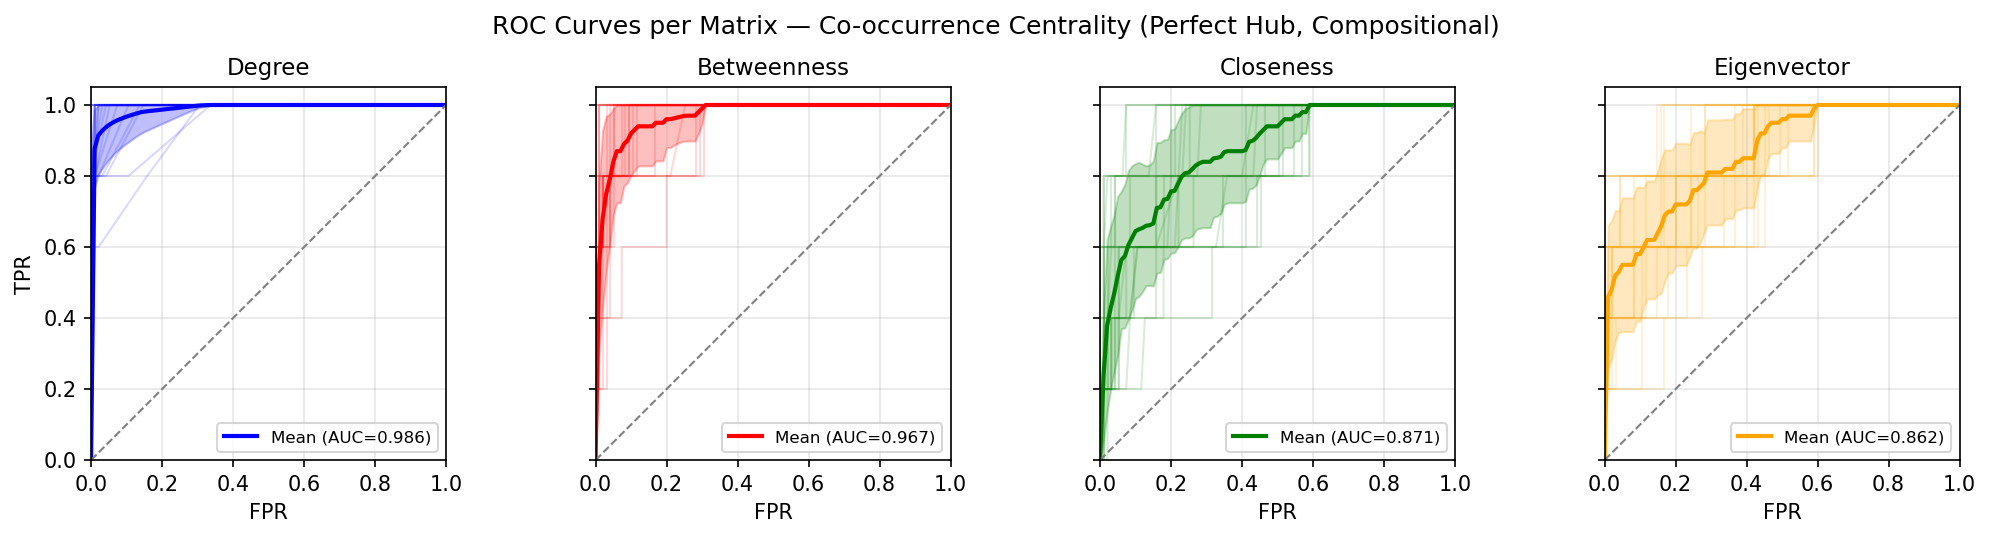

In [19]:
# ROC with individual curves + mean CI (Perfect Hub, Compositional)
base_fpr = np.linspace(0, 1, 101)
metric_names = ['degree', 'betweenness', 'closeness', 'eigenvector']
colors = ['blue', 'red', 'green', 'orange']

tprs_per_comp_metric = {m: [] for m in metric_names}

for i, (metric_name, color) in enumerate(zip(metric_names, colors)):
    for j in range(n_matrices_comp):
        G_comp_coocc = nx.from_numpy_array(network_comp_hub_perfL[j])
        nodes_ordered = list(G_comp_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_comp_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_comp_status, cent[metric_name])
        tpr_interp = np.interp(base_fpr, fpr_j, tpr_j)
        tpr_interp[0] = 0.0
        tprs_per_comp_metric[metric_name].append(tpr_interp)

with open('figure_data/rh_roc_perfect_comp.pkl', 'wb') as f:
    pickle.dump({
        'tprs_per_comp_metric': tprs_per_comp_metric,
        'base_fpr': base_fpr,
        'hub_comp_status': hub_comp_status,
        'n_matrices_comp': n_matrices_comp,
        'metric_names': metric_names,
        'colors': colors,
    }, f)

fig, axes = plt.subplots(1, len(metric_names), figsize=(14, 3.5), dpi=150, sharey=True)

for i, (ax, metric_name, color) in enumerate(zip(axes, metric_names, colors)):
    for j in range(n_matrices_comp):
        G_comp_coocc = nx.from_numpy_array(network_comp_hub_perfL[j])
        nodes_ordered = list(G_comp_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_comp_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_comp_status, cent[metric_name])
        ax.plot(fpr_j, tpr_j, color=color, alpha=0.15, lw=1)

    tprs_arr = np.array(tprs_per_comp_metric[metric_name])
    mean_tpr = tprs_arr.mean(axis=0)
    std_tpr = tprs_arr.std(axis=0)
    mean_auc = metrics.auc(base_fpr, mean_tpr)

    ax.plot(base_fpr, mean_tpr, color=color, lw=2, label=f'Mean (AUC={mean_auc:.3f})')
    ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                    color=color, alpha=0.25)
    ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
    ax.set_title(metric_name.title(), fontsize=11)
    ax.set_xlabel('FPR', fontsize=10)
    if i == 0:
        ax.set_ylabel('TPR', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('ROC Curves per Matrix — Co-occurrence Centrality (Perfect Hub, Compositional)', fontsize=12)
plt.tight_layout()
plt.show()

{'degree': 0.995428947368421,
 'betweenness': 0.9736447368421053,
 'closeness': 0.7946342105263157,
 'eigenvector': 0.8836631578947367}

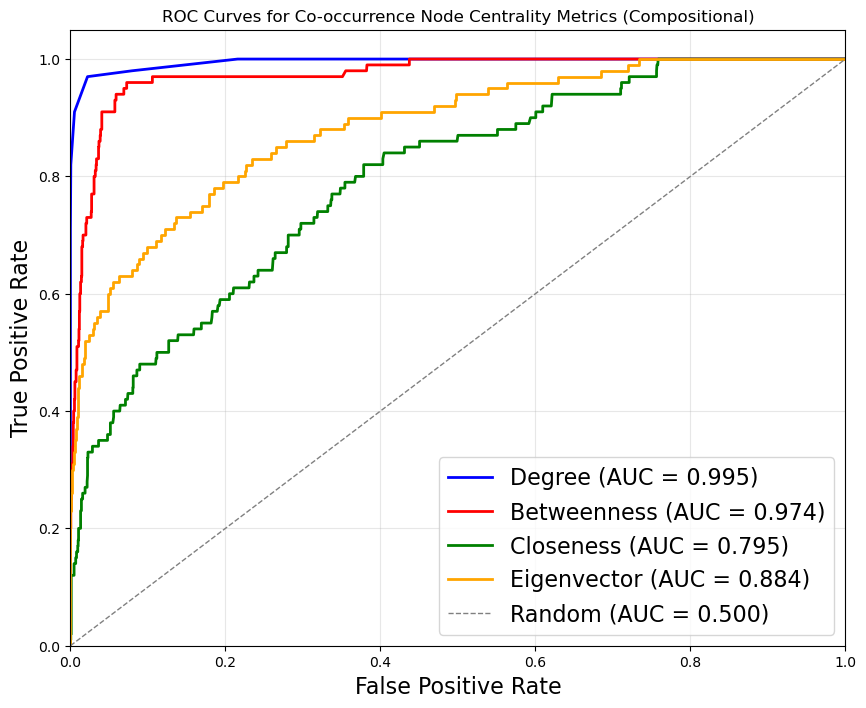

In [20]:
# ROC curve for classifying nodes as hubs for the less perfect hubs
# Using networks generated with get_coocc_network (pval_alpha set at the top)

# get actual hub status
binary_comp_hub = (hubMxL_comp[0] != 0).astype(int)
G_comp_actual = nx.from_numpy_array(binary_comp_hub)

degrees = dict(G_comp_actual.degree())
degree_threshold = 13
hub_comp_status = np.array([1 if degrees[node] > degree_threshold else 0 for node in G_comp_actual.nodes()])
assert(np.sum(hub_comp_status) == nModules)

# Calculate centrality metrics
centrality_comp_metrics = {}
for i in range(n_matrices_comp):
    G_comp_hub_coocc = nx.from_numpy_array(network_comp_hubL[i])
    nodes_ordered = list(G_comp_hub_coocc.nodes())
    assert(np.all(nodes_ordered == list(G_comp_actual.nodes())))

    # add the new centrality metrics to the arrays in the dictionary for this iteration
    centrality_comp_metrics = metrics_and_plotting.calculate_centrality_metrics(G_comp_hub_coocc, nodes_ordered, centrality_comp_metrics)

# plot ROC curves
all_hub_comp_status = np.tile(hub_comp_status, reps = n_matrices_comp)

with open('figure_data/rh_hub_roc_simple_imperfect_comp.pkl', 'wb') as f:
    pickle.dump({
        'centrality_comp_metrics': centrality_comp_metrics,
        'all_hub_comp_status': all_hub_comp_status,
        'hub_comp_status': hub_comp_status,
        'title': f'ROC Curves for Co-occurrence Node Centrality Metrics (Compositional)',
    }, f)

metrics_and_plotting.plot_hub_roc(centrality_comp_metrics, all_hub_comp_status, title=f'ROC Curves for Co-occurrence Node Centrality Metrics (Compositional)')

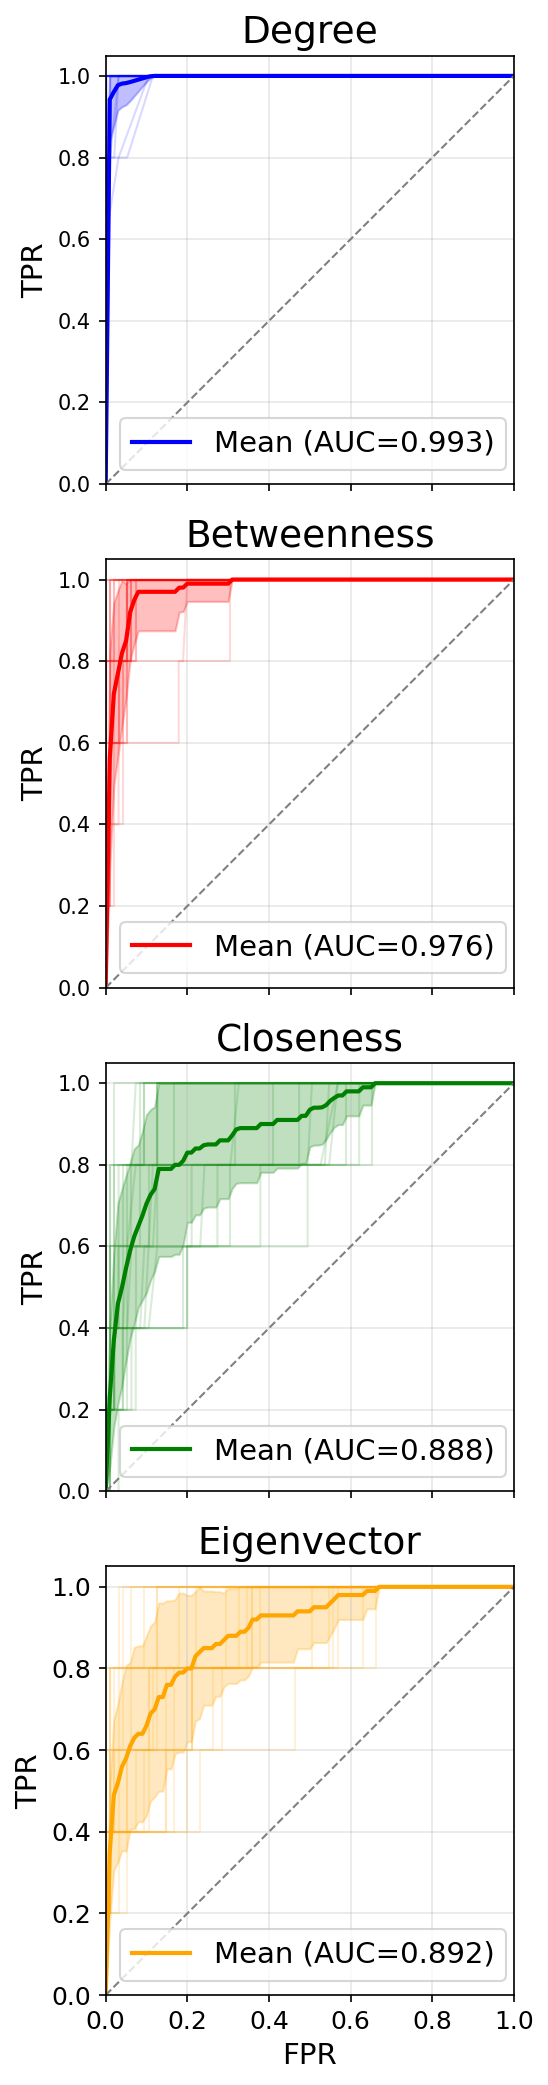

In [21]:
# ROC with individual curves + mean CI (Imperfect Hub, Compositional)
base_fpr = np.linspace(0, 1, 101)
metric_names = ['degree', 'betweenness', 'closeness', 'eigenvector']
colors = ['blue', 'red', 'green', 'orange']

tprs_per_comp_metric = {m: [] for m in metric_names}

for i, (metric_name, color) in enumerate(zip(metric_names, colors)):
    for j in range(n_matrices_comp):
        G_comp_coocc = nx.from_numpy_array(network_comp_hubL[j])
        nodes_ordered = list(G_comp_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_comp_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_comp_status, cent[metric_name])
        tpr_interp = np.interp(base_fpr, fpr_j, tpr_j)
        tpr_interp[0] = 0.0
        tprs_per_comp_metric[metric_name].append(tpr_interp)

with open('figure_data/rh_roc_imperfect_comp.pkl', 'wb') as f:
    pickle.dump({
        'tprs_per_comp_metric': tprs_per_comp_metric,
        'base_fpr': base_fpr,
        'hub_comp_status': hub_comp_status,
        'n_matrices_comp': n_matrices_comp,
        'metric_names': metric_names,
        'colors': colors,
    }, f)

fig, axes = plt.subplots(len(metric_names), 1, figsize=(5, 14), dpi=150, sharex=True)

for i, (ax, metric_name, color) in enumerate(zip(axes, metric_names, colors)):
    for j in range(n_matrices_comp):
        G_comp_coocc = nx.from_numpy_array(network_comp_hubL[j])
        nodes_ordered = list(G_comp_coocc.nodes())
        cent = metrics_and_plotting.calculate_centrality_metrics(G_comp_coocc, nodes_ordered, {})
        fpr_j, tpr_j, _ = metrics.roc_curve(hub_comp_status, cent[metric_name])
        ax.plot(fpr_j, tpr_j, color=color, alpha=0.15, lw=1)

    tprs_arr = np.array(tprs_per_comp_metric[metric_name])
    mean_tpr = tprs_arr.mean(axis=0)
    std_tpr = tprs_arr.std(axis=0)
    mean_auc = metrics.auc(base_fpr, mean_tpr)

    ax.plot(base_fpr, mean_tpr, color=color, lw=2, label=f'Mean (AUC={mean_auc:.3f})')
    ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1),
                    color=color, alpha=0.25)
    ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
    ax.set_title(metric_name.title(), fontsize=18)
    ax.set_ylabel('TPR', fontsize=14)
    if i == len(metric_names) - 1:
        ax.set_xlabel('FPR', fontsize=14)
    ax.legend(fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()